In [2]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)


In [3]:

# Create dataset
X = np.linspace(0,10,200).reshape(-1,1)
noise = np.random.normal(0,0.2,size=(200,1))
y = np.log(X+1) + noise



In [4]:

# Activation functions

def relu(z):
    return np.maximum(0,z)

def relu_derivative(z):
    return (z>0).astype(float)

In [5]:

# Initialize network

def initialize_network(input_size, hidden_size, num_hidden_layers):

    weights=[]
    biases=[]

    # input → first hidden
    weights.append(np.random.uniform(-1,1,(input_size,hidden_size)))
    biases.append(np.zeros((1,hidden_size)))

    # hidden → hidden
    for _ in range(num_hidden_layers-1):
        weights.append(np.random.uniform(-1,1,(hidden_size,hidden_size)))
        biases.append(np.zeros((1,hidden_size)))

    # last hidden → output
    weights.append(np.random.uniform(-1,1,(hidden_size,1)))
    biases.append(np.zeros((1,1)))

    return weights,biases

In [6]:

# Forward Pass

def forward(X,weights,biases):

    activations=[X]
    z_values=[]

    for i in range(len(weights)-1):

        z = activations[-1] @ weights[i] + biases[i]
        a = relu(z)

        z_values.append(z)
        activations.append(a)

    # output layer (linear)

    z = activations[-1] @ weights[-1] + biases[-1]
    z_values.append(z)
    activations.append(z)

    return activations,z_values


In [7]:

# Backpropagation

def backward(X,y,weights,biases,activations,z_values,lr):

    m = len(X)

    dA = (activations[-1] - y)

    for i in reversed(range(len(weights))):

        if i == len(weights)-1:

            dW = activations[i].T @ dA / m
            dB = np.sum(dA,axis=0,keepdims=True)/m

        else:

            dA = (dA @ weights[i+1].T) * relu_derivative(z_values[i])
            dW = activations[i].T @ dA / m
            dB = np.sum(dA,axis=0,keepdims=True)/m

        weights[i] -= lr * dW
        biases[i] -= lr * dB


In [8]:
# Training function

def train_network(hidden_layers):

    weights,biases = initialize_network(1,5,hidden_layers)

    lr = 0.01
    epochs = 2000

    losses=[]

    for epoch in range(epochs):

        activations,z_values = forward(X,weights,biases)

        y_hat = activations[-1]

        loss = np.mean((y_hat-y)**2)
        losses.append(loss)

        backward(X,y,weights,biases,activations,z_values,lr)

        if epoch % 500 == 0:
            print("Epoch:",epoch,"Loss:",loss)

    return weights,biases,losses

In [9]:
# Train networks


print("Training 2-layer network")
w2,b2,loss2 = train_network(1)

print("\nTraining 5-layer network")
w5,b5,loss5 = train_network(4)

print("\nTraining 10-layer network")
w10,b10,loss10 = train_network(9)


Training 2-layer network
Epoch: 0 Loss: 1.9567638926000714
Epoch: 500 Loss: 0.06186123165596165
Epoch: 1000 Loss: 0.0614639769129142
Epoch: 1500 Loss: 0.06129606837258157

Training 5-layer network
Epoch: 0 Loss: 3.707535083560375
Epoch: 500 Loss: 0.05606056868992559
Epoch: 1000 Loss: 0.04631499544071636
Epoch: 1500 Loss: 0.040830821540759885

Training 10-layer network
Epoch: 0 Loss: 3.2005228775918066
Epoch: 500 Loss: 0.4225361571797929
Epoch: 1000 Loss: 0.4225361571797929
Epoch: 1500 Loss: 0.4225361571797929


In [10]:
# Predictions
def predict(X,weights,biases):

    activations,_ = forward(X,weights,biases)
    return activations[-1]


y2 = predict(X,w2,b2)
y5 = predict(X,w5,b5)
y10 = predict(X,w10,b10)



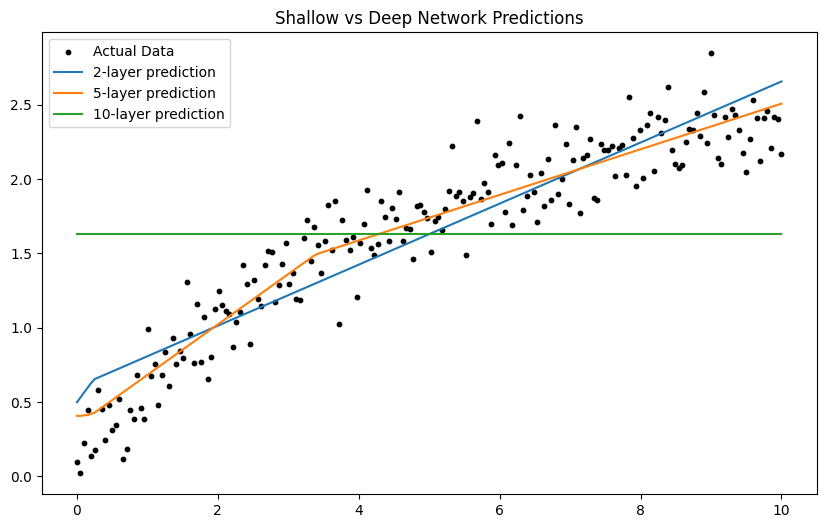

In [11]:
# Plot predictions

plt.figure(figsize=(10,6))

plt.scatter(X,y,label="Actual Data",color="black",s=10)

plt.plot(X,y2,label="2-layer prediction")
plt.plot(X,y5,label="5-layer prediction")
plt.plot(X,y10,label="10-layer prediction")

plt.legend()
plt.title("Shallow vs Deep Network Predictions")
plt.show()

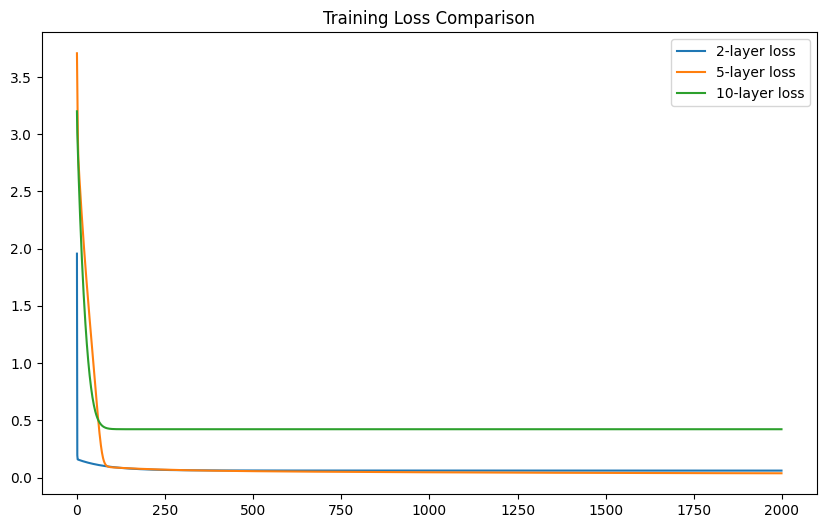

In [12]:
# Plot Loss curves
plt.figure(figsize=(10,6))

plt.plot(loss2,label="2-layer loss")
plt.plot(loss5,label="5-layer loss")
plt.plot(loss10,label="10-layer loss")

plt.legend()
plt.title("Training Loss Comparison")
plt.show()